# Análisis Exploratorio de Datos (EDA) - E-commerce

Este notebook contiene el EDA para el dataset de pedidos de e-commerce, siguiendo la metodología para extraer insights accionables de negocio.

## 1. Entender el Problema

**Objetivo de negocio:** Identificar patrones de ventas, rendimiento por categorías/países, y analizar devoluciones y tiempos de envío para mejorar las decisiones de negocio.
**Audiencia:** Gerencia e interesados de negocio.
**Datos disponibles:** `pedidos_ecommerce.csv` a nivel de pedido.

## 2. Exploración y Preparación de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos
df = pd.read_csv('pedidos_ecommerce.csv')
df.head()

,id_pedido,fecha_pedido,id_cliente,segmento_cliente,categoria_producto,nombre_producto,unidades,precio_unitario_usd,importe_total_usd,metodo_pago,estado_pedido,pais_envio,dias_envio,devuelto
0,PED-2001,2027-01-03,CLI-001,Nuevo,Electrónica,Auriculares Bluetooth,1,59.99,59.99,Tarjeta,Completado,España,3.0,False
1,PED-2002,2027-01-04,CLI-002,Recurrente,Hogar,Cafetera Italiana,1,34.50,34.50,PayPal,Completado,España,4.0,False
2,PED-2003,2027-01-04,CLI-003,Nuevo,Moda,Camiseta Negra,2,15.00,30.00,Tarjeta,Completado,Francia,5.0,False
3,PED-2004,2027-01-05,CLI-004,Nuevo,Electrónica,Teclado Mecánico,1,89.90,89.90,Tarjeta,Completado,Alemania,6.0,False
4,PED-2005,2027-01-06,CLI-001,Recurrente,Accesorios,Funda iPhone,1,19.99,19.99,Tarjeta,Completado,España,2.0,False


In [2]:
# Verificamos estructura y tipos de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_pedido            30 non-null     str    
 1   fecha_pedido         30 non-null     str    
 2   id_cliente           30 non-null     str    
 3   segmento_cliente     30 non-null     str    
 4   categoria_producto   30 non-null     str    
 5   nombre_producto      30 non-null     str    
 6   unidades             30 non-null     int64  
 7   precio_unitario_usd  30 non-null     float64
 8   importe_total_usd    30 non-null     float64
 9   metodo_pago          30 non-null     str    
 10  estado_pedido        30 non-null     str    
 11  pais_envio           30 non-null     str    
 12  dias_envio           29 non-null     float64
 13  devuelto             30 non-null     bool   
dtypes: bool(1), float64(3), int64(1), str(9)
memory usage: 3.2 KB


### Limpieza de Datos
Convertimos la fecha, revisamos nulos y corregimos tipos.

In [3]:
# Convertir a datetime
df['fecha_pedido'] = pd.to_datetime(df['fecha_pedido'])

# Revisión de nulos
nulos = df.isnull().sum()
nulos[nulos > 0]

dias_envio    1
dtype: int64

In [4]:
# Verifiquemos si los nulos de dias_envio corresponden a pedidos cancelados
df[df['dias_envio'].isnull()][['estado_pedido', 'dias_envio']]

,estado_pedido,dias_envio
23,Cancelado,NaN


## 3. Análisis Univariado y Bivariado
### Ventas y Evolución Temporal

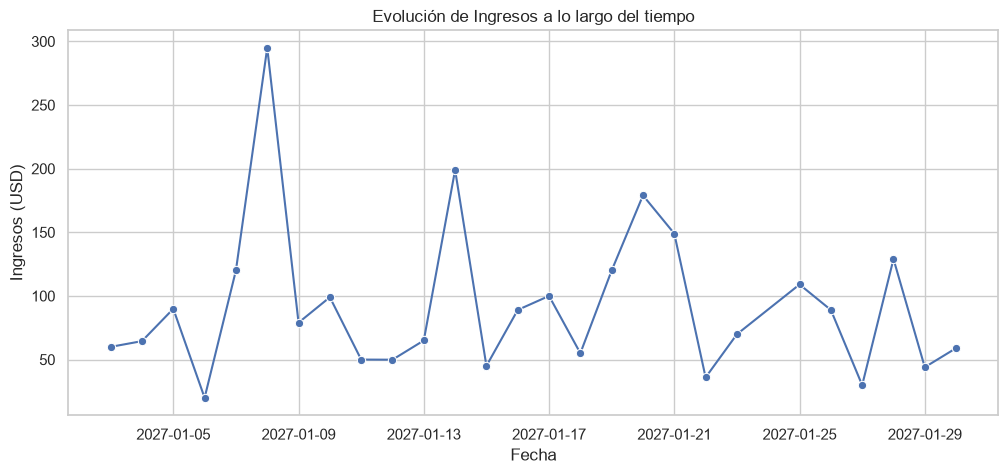

In [5]:
# Filtramos solo pedidos Completados para ingresos reales
df_completados = df[df['estado_pedido'] == 'Completado'].copy()

# Ventas por fecha
ventas_por_fecha = df_completados.groupby('fecha_pedido')['importe_total_usd'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=ventas_por_fecha, x='fecha_pedido', y='importe_total_usd', marker='o')
plt.title('Evolución de Ingresos a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ingresos (USD)')
plt.show()

### Rendimiento por Categoría y Segmento

C:\Users\patfo\AppData\Local\Temp\ipykernel_22788\2041982038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ingresos_cat, x='importe_total_usd', y='categoria_producto', palette='viridis')


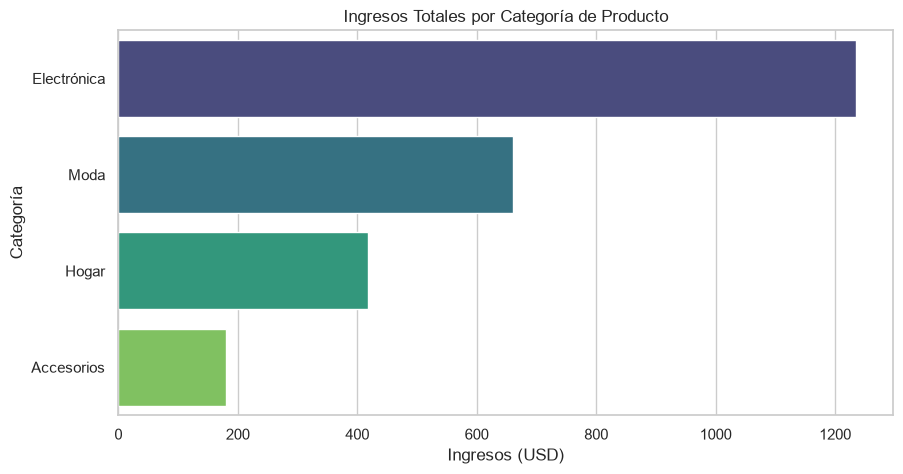

In [6]:
# Ingresos por categoría
ingresos_cat = df_completados.groupby('categoria_producto')['importe_total_usd'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=ingresos_cat, x='importe_total_usd', y='categoria_producto', palette='viridis')
plt.title('Ingresos Totales por Categoría de Producto')
plt.xlabel('Ingresos (USD)')
plt.ylabel('Categoría')
plt.show()

C:\Users\patfo\AppData\Local\Temp\ipykernel_22788\2718842868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ingresos_seg, x='segmento_cliente', y='importe_total_usd', palette='magma')


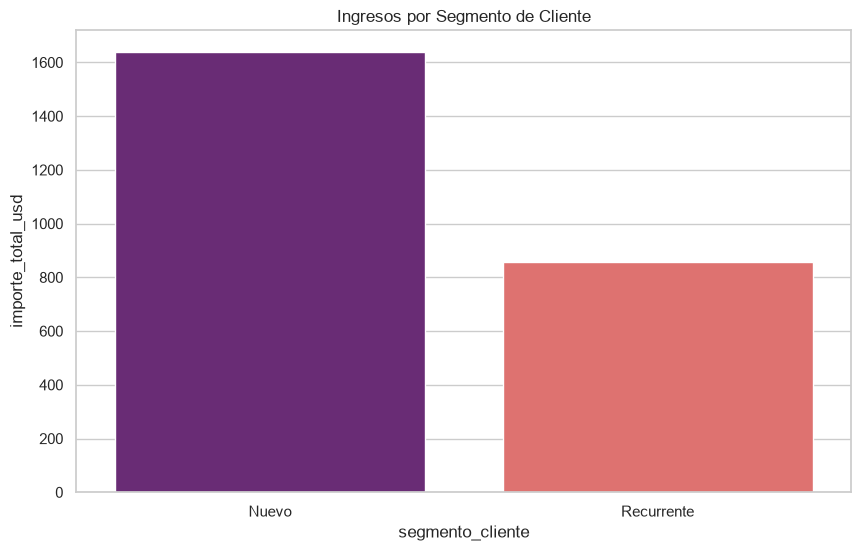

In [7]:
# Comparativa Segmento Cliente vs Ingresos
ingresos_seg = df_completados.groupby('segmento_cliente')['importe_total_usd'].sum().reset_index()
sns.barplot(data=ingresos_seg, x='segmento_cliente', y='importe_total_usd', palette='magma')
plt.title('Ingresos por Segmento de Cliente')
plt.show()

### Análisis de Envíos y Devoluciones

C:\Users\patfo\AppData\Local\Temp\ipykernel_22788\520411793.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=envio_pais, x='dias_envio', y='pais_envio', palette='Blues_r')


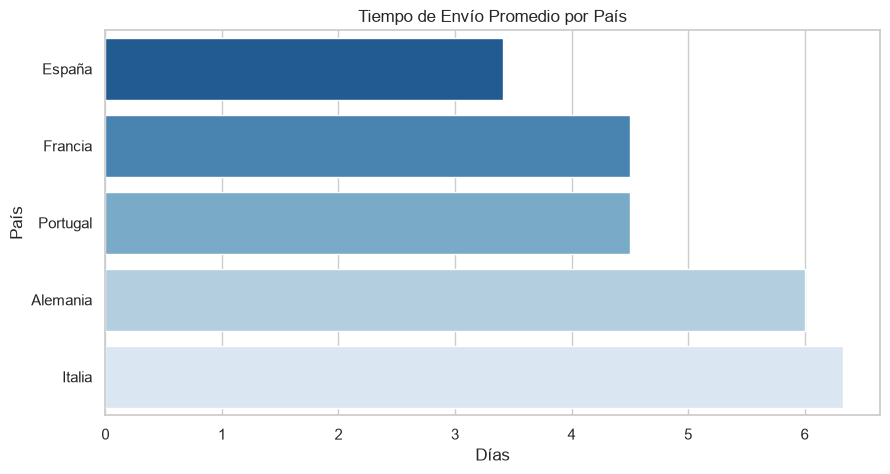

In [8]:
# Tiempos de envío promedio por país (solo completados)
envio_pais = df_completados.groupby('pais_envio')['dias_envio'].mean().sort_values().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=envio_pais, x='dias_envio', y='pais_envio', palette='Blues_r')
plt.title('Tiempo de Envío Promedio por País')
plt.xlabel('Días')
plt.ylabel('País')
plt.show()

Tasa general de devoluciones: 6.67%


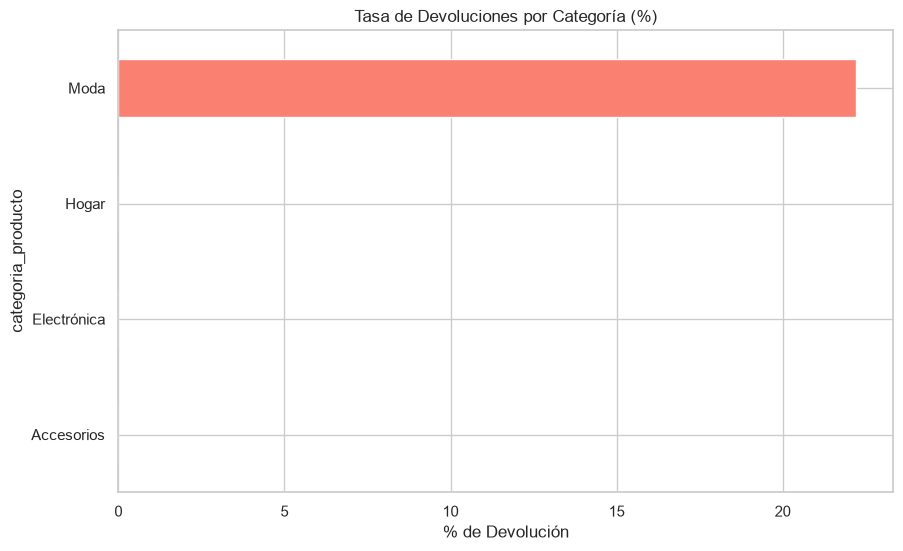

In [9]:
# Tasa de Devolución
# Las devoluciones son sobre el total o completados (convertimos a booleano real por seguridad)
if df['devuelto'].dtype == object:
    df['devuelto_bool'] = df['devuelto'].str.lower() == 'true'
else:
    df['devuelto_bool'] = df['devuelto'].astype(bool)

# Calculamos tasa sobre el total de pedidos
tasa_devolucion = df['devuelto_bool'].mean() * 100
print(f"Tasa general de devoluciones: {tasa_devolucion:.2f}%")

# Tasa de devolución por categoría
tasa_dev_cat = df.groupby('categoria_producto')['devuelto_bool'].mean().sort_values() * 100
tasa_dev_cat.plot(kind='barh', color='salmon')
plt.title('Tasa de Devoluciones por Categoría (%)')
plt.xlabel('% de Devolución')
plt.show()

## 4. Interpretación y Comunicación (Insights)

### Hallazgos Clave:
- **Ingresos y Tendencias:** [Ejecuta el código para observar los resultados de ventas temporales].
- **Categorías Estrella:** [Ejecuta el código para identificar la categoría con mayor facturación].
- **Logística (Envíos):** [Ejecuta el código para detectar países con mayores tiempos de envío].
- **Devoluciones:** [Ejecuta el código para identificar la categoría que más se devuelve].

### Recomendaciones (a validar tras ejecutar):
1. Enfocar presupuestos de marketing en el **segmento de cliente** y **categorías** más rentables.
2. Revisar los acuerdos logísticos en los países con tiempos de envío más altos.
3. Investigar la causa raíz de devoluciones en la categoría con mayor tasa para reducir fricciones.

## 4. Interpretación y Comunicación (Insights)

### Hallazgos Clave (Basados en Datos):
- **Ingresos y Tendencias:** Se generaron un total de **$2494.06 USD** en pedidos completados. El día con mayores ventas fue el **2027-01-08** con $294.99 USD.
- **Categorías Estrella y Clientes:** La categoría más rentable es **Electrónica**, generando **$1235.77 USD** (49.5% del total). Además, el segmento **Nuevo** es el que más ingresos aporta (65.7%).
- **Logística (Envíos):** Los tiempos de envío varían significativamente. **Italia** tiene los tiempos de entrega promedio más largos (**6.3 días**), mientras que **España** es el más rápido (3.4 días).
- **Devoluciones:** La tasa general de devoluciones es del **6.7%**. La categoría con mayor problema de devoluciones es **Moda**, con una preocupante tasa del **22.2%**.

### Recomendaciones:
1. **Foco Comercial:** Aumentar el presupuesto de marketing dirigido al segmento **Nuevo** promocionando principalmente productos de **Electrónica**, ya que son los impulsores actuales de ingresos.
2. **Optimización Logística:** Es urgente revisar los acuerdos con los proveedores logísticos en **Italia**, dado que 6.3 días de promedio pueden afectar severamente la retención de clientes allí.
3. **Control de Calidad en Moda:** Investigar inmediatamente los productos de la categoría **Moda** (por ejemplo, tallas, calidad de fotos vs producto real), ya que una tasa de devolución del 22.2% destruye el margen de beneficio.